# E0.5 — Shortcut audit (train/dev only)

**Question.** Can a detector tell bonafide from spoof by cues that are *not* the speech itself, such as edge silence, level, clipping or bandwidth? Noise suppression, VAD and AGC wipe those cues out under noise, which would explain part of the clean→noisy gap ([Müller et al. 2021](https://arxiv.org/abs/2106.12914)). The eval reads only the **first 4.04 s** of each clip, so leading silence weighs most.

**Inputs** (this notebook only reads cached files, so it reruns in seconds):
- `data/audit/features_v1.csv` from `scripts/shortcut_features.py`: per-file statistics for train and dev.
- Probe scores from `scripts/local_eval.py` on the `probe_*` sets (`scripts/build_probe_sets.py`). Set `PROBE_SCORES` to the model being audited (REF-0 once recovered).

Only train/dev data is used. Nothing here looks at progress or eval audio.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from IPython.display import Audio, display, Markdown

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FEATURES = REPO / "data/audit/features_v1.csv"
PROBE_SCORES = REPO / "SLS_setup/exp/qwen-asr-1.7B-sls-e2e_epoch100_bs16_20260920231624/local_eval/best_model_epoch35/scores"
PROBE_ROOT = REPO / "data/dev_noisy_sim/probes_v1"

# reference palette: categorical slots 1-2 (validated pair), chart chrome, blue<->red diverging with gray midpoint
COLORS = {"bonafide": "#2a78d6", "spoof": "#eb6834"}
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
DIVERGING = LinearSegmentedColormap.from_list("bluered", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#c3c2b7",
                     "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11})

df = pd.read_csv(FEATURES)
df["y_spoof"] = (df["label"] == "spoof").astype(int)
FEATS = ["duration", "lead_sil_35", "trail_sil_35", "lead_sil_45", "trail_sil_45", "nonspeech_frac",
         "crop_nonspeech_frac", "rms_db", "rms_active_db", "peak_db", "clip_ratio", "dc_offset",
         "rolloff99_hz", "noise_floor_db"]
print(f"{len(df)} files:"); df.groupby(["split", "src", "label"]).size().unstack()

90989 files:


label          bonafide  spoof
split src                     
dev   offline      1452   6287
      online       1397   6068
train offline      7463  31197
      online       6890  30235

## 1. Per-class summary (medians)
Each cell is the median for split × src × lang × label. Look for features where bonafide and spoof differ consistently in every (src, lang) cell.

In [2]:
KEY = ["lead_sil_35", "trail_sil_35", "crop_nonspeech_frac", "rms_active_db", "peak_db", "clip_ratio", "rolloff99_hz", "noise_floor_db", "duration"]
summary = df.groupby(["split", "src", "lang", "label"])[KEY].median().round(3)
summary

lead_sil_35  trail_sil_35  crop_nonspeech_frac  \
split src     lang label                                                      
dev   offline en   bonafide         0.23         0.360                0.249   
                   spoof            0.09         0.099                0.214   
              zh   bonafide         0.06         0.122                0.184   
                   spoof            0.05         0.089                0.149   
      online  en   bonafide         0.05         0.100                0.204   
                   spoof            0.05         0.110                0.189   
              zh   bonafide         0.04         0.100                0.164   
                   spoof            0.04         0.100                0.139   
train offline en   bonafide         0.19         0.300                0.189   
                   spoof            0.09         0.100                0.179   
              zh   bonafide         0.05         0.120                0.154   
                   spoof            0.04         0.088                0.119   
      online  en   bonafide         0.05         0.110                0.164   
                   spoof            0.05         0.110                0.164   
              zh   bonafide         0.05         0.100                0.139   
                   spoof            0.04         0.100                0.114   

                             rms_active_db  peak_db  clip_ratio  rolloff99_hz  \
split src     lang label                                                        
dev   offline en   bonafide        -25.060   -6.273         0.0      4671.875   
                   spoof           -23.448   -4.901         0.0      4578.125   
              zh   bonafide        -22.024   -6.028         0.0      3421.875   
                   spoof           -20.657   -4.335         0.0      3187.500   
      online  en   bonafide        -18.788   -1.104         0.0      4281.250   
                   spoof           -17.904   -0.926         0.0      4000.000   
              zh   bonafide        -18.472   -2.907         0.0      3281.250   
                   spoof           -17.158   -1.562         0.0      2921.875   
train offline en   bonafide        -23.924   -6.189         0.0      4656.250   
                   spoof           -22.344   -4.650         0.0      4203.125   
              zh   bonafide        -22.343   -6.147         0.0      4421.875   
                   spoof           -20.881   -4.785         0.0      3968.750   
      online  en   bonafide        -17.660   -0.935         0.0      3937.500   
                   spoof           -16.985   -0.718         0.0      3718.750   
              zh   bonafide        -17.911   -2.229         0.0      3656.250   
                   spoof           -16.292   -0.867         0.0      3515.625   

                             noise_floor_db  duration  
split src     lang label                               
dev   offline en   bonafide         -63.105     7.320  
                   spoof            -62.734     6.693  
              zh   bonafide         -64.242     7.488  
                   spoof            -55.785     6.827  
      online  en   bonafide         -62.361     6.800  
                   spoof            -62.320     6.400  
              zh   bonafide         -62.394     7.300  
                   spoof            -52.817     6.700  
train offline en   bonafide         -57.609     7.831  
                   spoof            -56.525     7.070  
              zh   bonafide         -61.365     7.500  
                   spoof            -52.281     6.752  
      online  en   bonafide         -54.928     7.000  
                   spoof            -55.534     6.700  
              zh   bonafide         -55.381     7.200  
                   spoof            -48.238     6.700

## 2. Distributions by label
Train split, faceted by src × lang. Bonafide is blue and spoof is orange. Distributions are normalised per class, because spoof outnumbers bonafide about 4:1. Values outside the 0.5–99.5 % range are clipped into the edge bins, so spikes at the extremes are pile-ups, not modes.

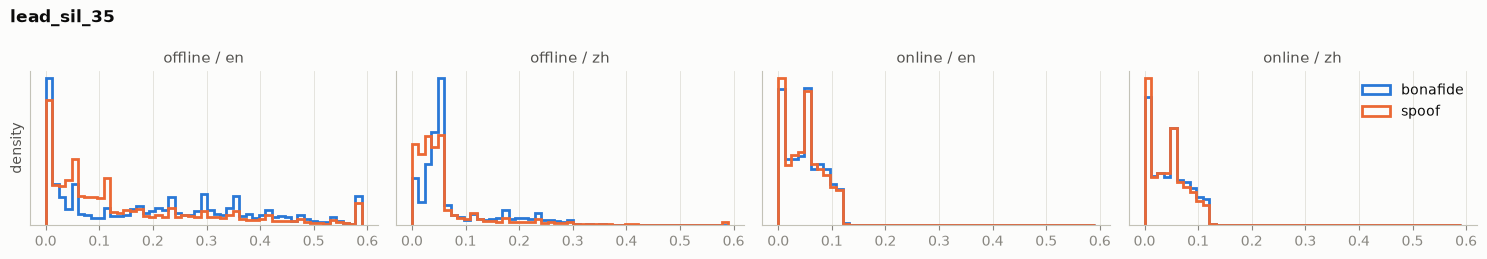

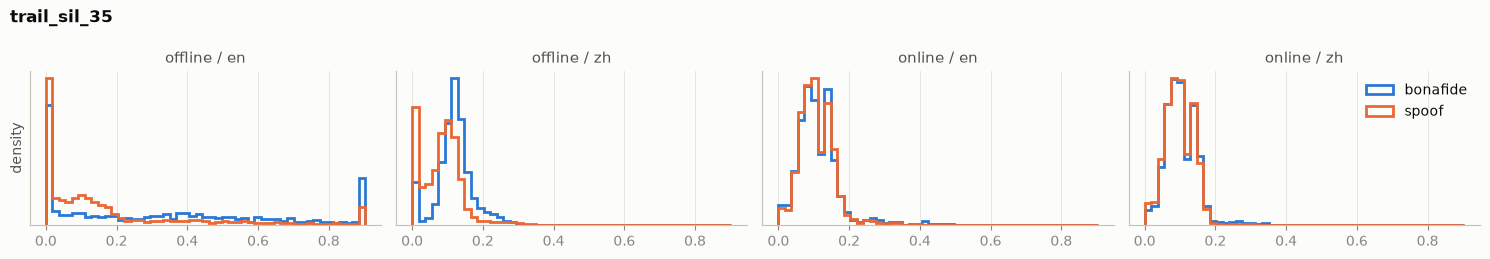

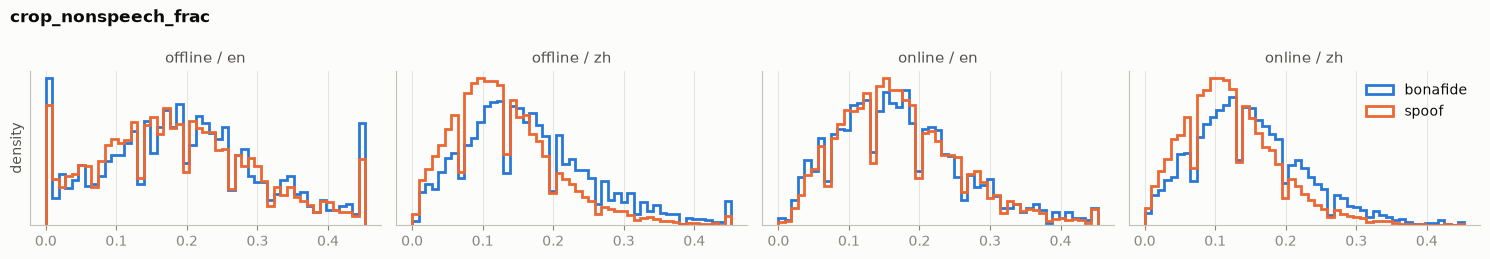

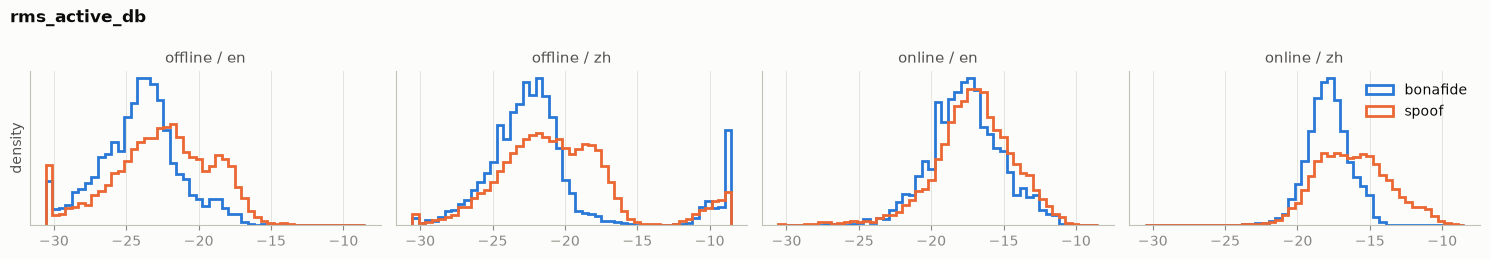

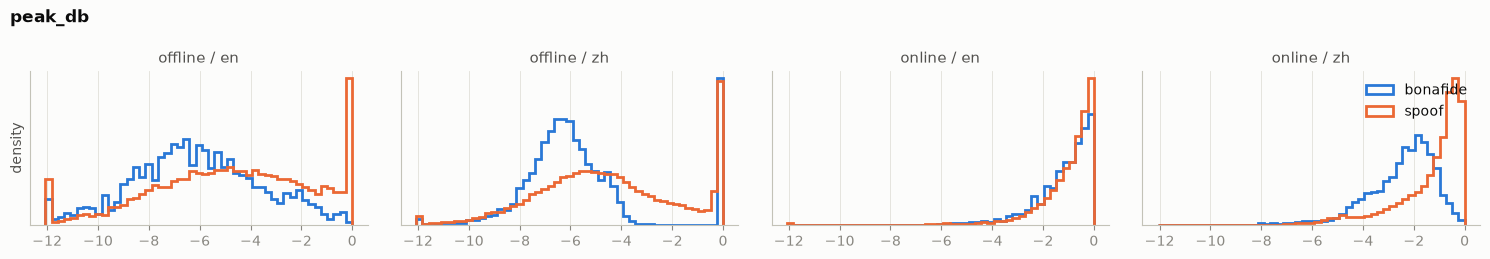

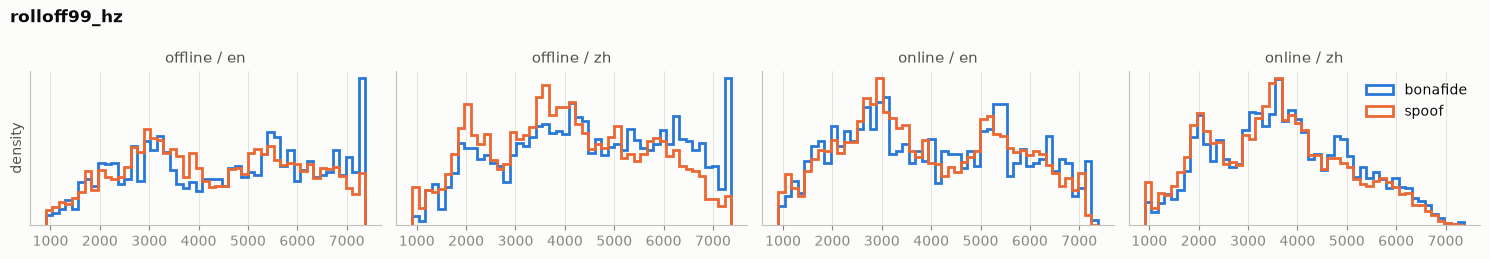

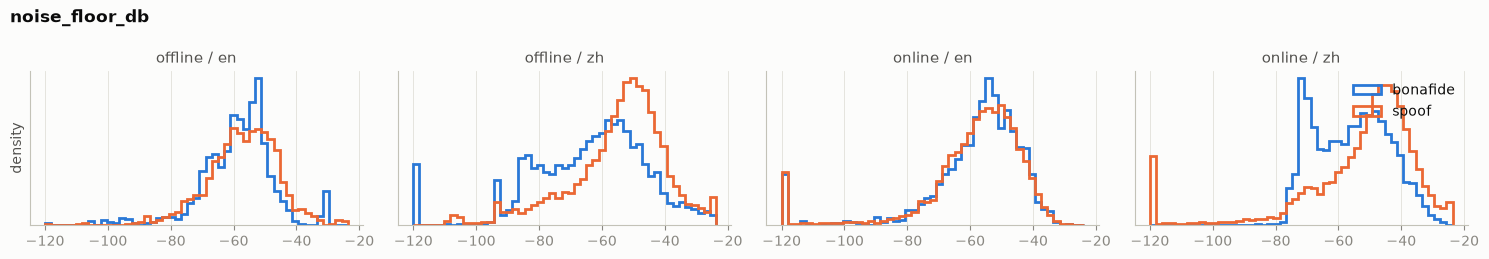

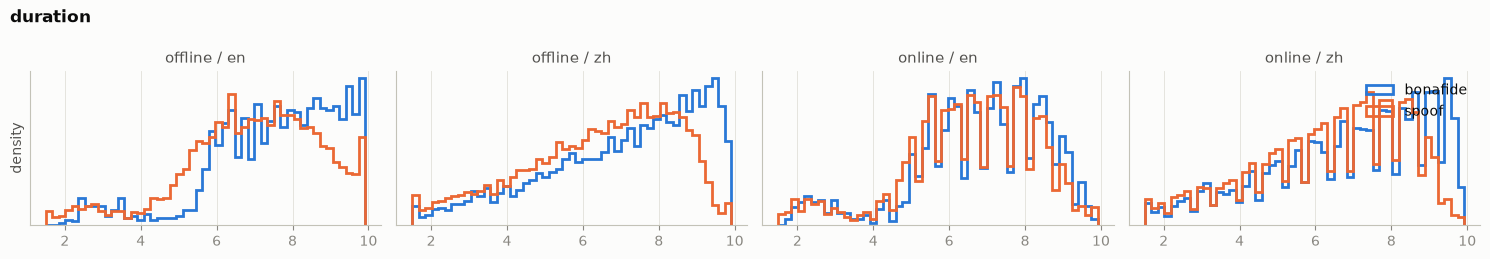

In [3]:
PLOT_FEATS = ["lead_sil_35", "trail_sil_35", "crop_nonspeech_frac", "rms_active_db", "peak_db", "rolloff99_hz", "noise_floor_db", "duration"]
cells = [("offline", "en"), ("offline", "zh"), ("online", "en"), ("online", "zh")]
tr = df[df.split == "train"]
for feat in PLOT_FEATS:
    lo, hi = tr[feat].quantile([0.005, 0.995])
    bins = np.linspace(lo, hi, 50)
    fig, axes = plt.subplots(1, 4, figsize=(15, 2.6), sharey=False)
    for ax, (src, lang) in zip(axes, cells):
        sub = tr[(tr.src == src) & (tr.lang == lang)]
        for label in ("bonafide", "spoof"):
            ax.hist(sub.loc[sub.label == label, feat].clip(lo, hi), bins=bins, density=True,
                    histtype="step", linewidth=2, color=COLORS[label], label=label)
        ax.set_title(f"{src} / {lang}", color=INK2); ax.set_yticks([])
    axes[0].set_ylabel("density")
    fig.suptitle(feat, x=0.01, ha="left", fontweight="bold")
    axes[-1].legend(frameon=False, loc="upper right")
    fig.tight_layout(); plt.show()

## 3. Single-feature AUC per cell
This is the AUC of each feature alone for predicting spoof, per (split, src, lang). 0.5 means no information; above 0.70 or below 0.30 is a **shortcut candidate**. Red means higher values go with spoof, and blue means higher values go with bonafide.

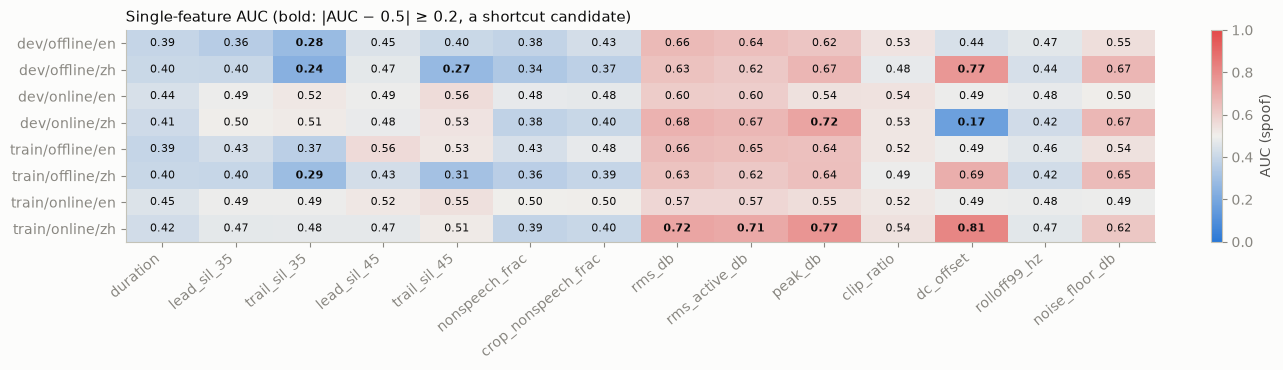

**Flagged (|AUC−0.5| ≥ 0.2):** `dev/offline/en` · trail_sil_35 = 0.28, `dev/offline/zh` · trail_sil_35 = 0.24, `dev/offline/zh` · trail_sil_45 = 0.27, `dev/offline/zh` · dc_offset = 0.77, `dev/online/zh` · peak_db = 0.72, `dev/online/zh` · dc_offset = 0.17, `train/offline/zh` · trail_sil_35 = 0.29, `train/online/zh` · rms_db = 0.72, `train/online/zh` · rms_active_db = 0.71, `train/online/zh` · peak_db = 0.77, `train/online/zh` · dc_offset = 0.81

In [4]:
rows = []
for (split, src, lang), sub in df.groupby(["split", "src", "lang"]):
    rows.append({"cell": f"{split}/{src}/{lang}", **{f: roc_auc_score(sub.y_spoof, sub[f]) for f in FEATS}})
auc = pd.DataFrame(rows).set_index("cell")
fig, ax = plt.subplots(figsize=(13, 3.8))
im = ax.imshow(auc.values, cmap=DIVERGING, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(FEATS)), FEATS, rotation=40, ha="right"); ax.set_yticks(range(len(auc)), auc.index)
ax.grid(False)
for i in range(auc.shape[0]):
    for j in range(auc.shape[1]):
        v = auc.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color=INK, fontweight="bold" if abs(v - 0.5) >= 0.2 else "normal")
fig.colorbar(im, ax=ax, label="AUC (spoof)", fraction=0.025)
ax.set_title("Single-feature AUC (bold: |AUC − 0.5| ≥ 0.2, a shortcut candidate)", loc="left")
fig.tight_layout(); plt.show()
flags = auc.stack()[lambda s: (s - 0.5).abs() >= 0.2]
display(Markdown("**Flagged (|AUC−0.5| ≥ 0.2):** " + (", ".join(f"`{c}` · {f} = {v:.2f}" for (c, f), v in flags.items()) or "none")))

## 4. Shortcut capacity: all features together
This is the 5-fold cross-validated AUC of a logistic regression on all 14 non-speech statistics, per cell. It is an upper bound on how much a model *could* learn from these cues alone.

In [5]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
cap = {}
for (split, src, lang), sub in df.groupby(["split", "src", "lang"]):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
    cap[f"{split}/{src}/{lang}"] = cross_val_score(clf, sub[FEATS].fillna(0), sub.y_spoof, cv=cv, scoring="roc_auc").mean()
pd.Series(cap, name="CV AUC (all features)").round(3).to_frame()

,CV AUC (all features)
dev/offline/en,0.749
dev/offline/zh,0.861
dev/online/en,0.658
dev/online/zh,0.904
train/offline/en,0.734
train/offline/zh,0.799
train/online/en,0.615
train/online/zh,0.878


## 5. Model probes: does P(spoof) move when only non-speech cues change?
These are 1,000 dev-online clips. For each probe and label we show the mean change in P(spoof) against the original clip, and the share of clips whose decision at 0.5 flips. A probe with **label-dependent** movement, or a large flip rate, means the model reacts to that cue.

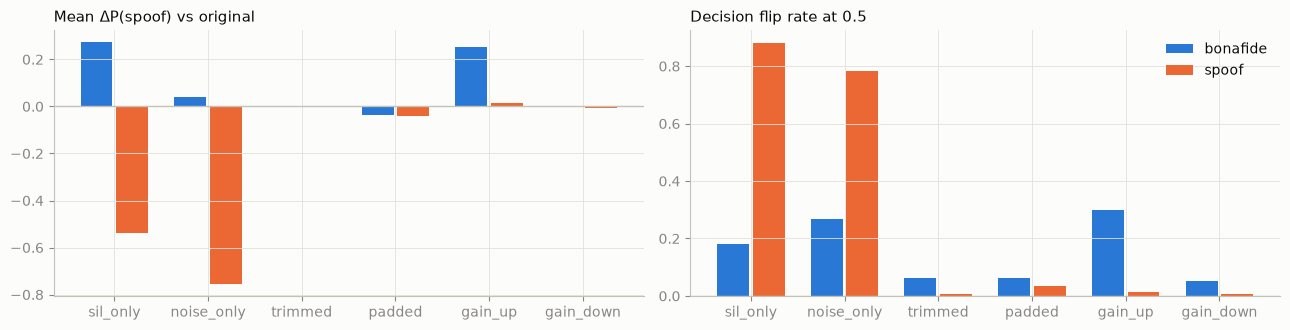

,probe,label,n,mean_dP,flip_rate,pred_spoof_rate,pred_spoof_rate_orig
0,sil_only,bonafide,187,0.274,0.182,0.053,0.128
1,sil_only,spoof,813,-0.537,0.882,0.100,0.982
2,noise_only,bonafide,187,0.040,0.267,0.182,0.128
3,noise_only,spoof,813,-0.754,0.784,0.205,0.982
4,trimmed,bonafide,187,0.003,0.064,0.150,0.128
5,trimmed,spoof,813,-0.001,0.007,0.982,0.982
6,padded,bonafide,187,-0.037,0.064,0.086,0.128
7,padded,spoof,813,-0.041,0.033,0.948,0.982
8,gain_up,bonafide,187,0.252,0.299,0.428,0.128
9,gain_up,spoof,813,0.016,0.012,0.994,0.982


In [6]:
def read_scores(name):
    s = pd.read_csv(PROBE_SCORES / f"{name}.txt", sep=" ", header=None, names=["path", "p"])
    m = pd.read_csv(PROBE_ROOT / name.removeprefix("probe_") / "meta.csv")
    return m.merge(s, on="path")
orig = read_scores("probe_orig")[["source_utt", "label", "p"]].rename(columns={"p": "p_orig"})
PROBES = ["sil_only", "noise_only", "trimmed", "padded", "gain_up", "gain_down"]
res = []
for probe in PROBES:
    d = read_scores(f"probe_{probe}").merge(orig, on=["source_utt", "label"])
    for label, g in d.groupby("label"):
        res.append({"probe": probe, "label": label, "n": len(g), "mean_dP": (g.p - g.p_orig).mean(),
                    "flip_rate": ((g.p >= 0.5) != (g.p_orig >= 0.5)).mean(),
                    "pred_spoof_rate": (g.p >= 0.5).mean(), "pred_spoof_rate_orig": (g.p_orig >= 0.5).mean()})
res = pd.DataFrame(res)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
x = np.arange(len(PROBES)); w = 0.38
for k, label in enumerate(("bonafide", "spoof")):
    r = res[res.label == label].set_index("probe").loc[PROBES]
    for ax, col in zip(axes, ("mean_dP", "flip_rate")):
        ax.bar(x + (k - 0.5) * w, r[col], width=w - 0.04, color=COLORS[label], label=label)
for ax, title in zip(axes, ("Mean ΔP(spoof) vs original", "Decision flip rate at 0.5")):
    ax.set_xticks(x, PROBES); ax.set_title(title, loc="left"); ax.axhline(0, color="#c3c2b7", linewidth=1)
axes[1].legend(frameon=False)
fig.tight_layout(); plt.show()
res.round(3)

### Listening: the bonafide clips most affected by +10 dB gain

In [7]:
d = read_scores("probe_gain_up").merge(orig, on=["source_utt", "label"])
d = d[d.label == "bonafide"].assign(dP=lambda t: t.p - t.p_orig).sort_values("dP", ascending=False).head(3)
for _, r in d.iterrows():
    display(Markdown(f"`{r.source_utt}`: P(spoof) {r.p_orig:.3f} → {r.p:.3f}"))
    display(Audio(str(PROBE_ROOT / "orig" / r.path)), Audio(str(PROBE_ROOT / "gain_up" / r.path)))

`online/zh/Dev_002192.wav`: P(spoof) 0.015 → 0.989

`online/zh/Dev_002157.wav`: P(spoof) 0.003 → 0.969

`online/zh/Dev_002318.wav`: P(spoof) 0.017 → 0.983

## 6. Conclusions (audited model: local Qwen3-ASR-1.7B e2e, epoch 35; re-run with REF-0 once recovered)

1. **Level is a real cue, and the model uses it.**
   - Spoof is louder than bonafide in every cell (active RMS and peak, single-feature AUC 0.60–0.77; strongest in online/zh).
   - The probe confirms the model reacts to it. At **+10 dB, 30 % of bonafide clips flip to spoof** (mean ΔP(spoof) +0.25, bonafide recall 87 % → 57 %). At −10 dB almost nothing changes.
   - Platform AGC and limiters move level and peaks under noise, so this cue is unreliable at eval.
   - → **Promote random gain (±10 dB) + AGC/limiter augmentation (part of A2.7) to P0.**
2. **Edge silence differs, but the model barely uses it.**
   - Offline bonafide has more trailing silence, plus leading silence in en (AUC 0.24–0.29). Online transmission equalises this (AUC ≈ 0.5).
   - Trimming or padding edge silence flips only 1–6 % of decisions.
   - → **A2.9 (silence/VAD robustness) stays P1, not P0.**
3. **No hidden silence or noise shortcut.**
   - With the speech removed (`sil_only`, `noise_only`), predictions collapse toward *bonafide* (predicted-spoof rate 10–20 %) rather than keeping the label.
   - The model needs speech evidence. Without it, it falls back to bonafide, which is the same direction as the H1 prior collapse seen on the noisy sim sets.
4. **The dataset carries non-speech differences in zh.**
   - All 14 statistics together give a CV AUC of 0.80–0.90 in the zh cells and 0.62–0.75 in en.
   - Spoof zh has a higher noise floor (about −55 vs −64 dB) and lower 99 % roll-off.
   - Added noise masks both, which is plausibly part of the clean→noisy gap. Augmentation should randomise noise floor and bandwidth independently of the label (A2.7, already planned).
5. **The DC-offset AUC is spurious.** It is 0.77–0.81 in some zh cells but **0.17 in dev/online/zh**: the direction flips between train and dev. It's cheap to neutralise with a random high-pass in augmentation. Low priority.